In [1]:
!pip install vaderSentiment -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.9 MB/s eta 0:00:00


In [2]:
import pandas as pd

df = pd.read_csv('employee_reviews.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (67529, 17)

Columns: ['Unnamed: 0', 'company', 'location', 'dates', 'job-title', 'summary', 'pros', 'cons', 'advice-to-mgmt', 'overall-ratings', 'work-balance-stars', 'culture-values-stars', 'carrer-opportunities-stars', 'comp-benefit-stars', 'senior-mangemnet-stars', 'helpful-count', 'link']

First 3 rows:


,Unnamed: 0,company,location,dates,job-title,summary,pros,cons,advice-to-mgmt,overall-ratings,work-balance-stars,culture-values-stars,carrer-opportunities-stars,comp-benefit-stars,senior-mangemnet-stars,helpful-count,link
0,1,google,none,"Dec 11, 2018",Current Employee - Anonymous Employee,Best Company to work for,People are smart and friendly,Bureaucracy is slowing things down,none,5.0,4.0,5.0,5.0,4.0,5.0,0,https://www.glassdoor.com/Reviews/Google-Revie...
1,2,google,"Mountain View, CA","Jun 21, 2013",Former Employee - Program Manager,"Moving at the speed of light, burn out is inev...","1) Food, food, food. 15+ cafes on main campus ...",1) Work/life balance. What balance? All those ...,1) Don't dismiss emotional intelligence and ad...,4.0,2.0,3.0,3.0,5.0,3.0,2094,https://www.glassdoor.com/Reviews/Google-Revie...
2,3,google,"New York, NY","May 10, 2014",Current Employee - Software Engineer III,Great balance between big-company security and...,"* If you're a software engineer, you're among ...","* It *is* becoming larger, and with it comes g...",Keep the focus on the user. Everything else wi...,5.0,5.0,4.0,5.0,5.0,4.0,949,https://www.glassdoor.com/Reviews/Google-Revie...


In [3]:
# companies are in the data
print("Companies:\n", df['company'].value_counts())

# rating distribution
print("\nRating distribution:\n", df['overall-ratings'].value_counts().sort_index())

# missing values in the text columns
print("\nMissing values:")
print(df[['summary', 'pros', 'cons']].isnull().sum())

Companies:
 company
amazon       26430
microsoft    17930
apple        12950
google        7819
facebook      1590
netflix        810
Name: count, dtype: int64

Rating distribution:
 overall-ratings
1.0     3906
2.0     5282
3.0    12653
4.0    22498
5.0    23190
Name: count, dtype: int64

Missing values:
summary    127
pros         0
cons         0
dtype: int64


In [4]:
df['review_text'] = df['pros'].fillna('') + ' ' + df['cons'].fillna('')

# Remove rows where review_text is empty
df = df[df['review_text'].str.strip().str.len() > 10].copy()

# Keep only the columns we need
df_clean = df[['company', 'overall-ratings', 'pros', 'cons', 'review_text']].copy()
df_clean = df_clean.rename(columns={'overall-ratings': 'rating'})

# Convert rating to numeric
df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')
df_clean = df_clean.dropna(subset=['rating'])

print(f"Clean dataset: {df_clean.shape[0]} reviews")
print(df_clean.head(3))

Clean dataset: 67529 reviews
  company  rating                                               pros  \
0  google     5.0                      People are smart and friendly   
1  google     4.0  1) Food, food, food. 15+ cafes on main campus ...   
2  google     5.0  * If you're a software engineer, you're among ...   

                                                cons  \
0                 Bureaucracy is slowing things down   
1  1) Work/life balance. What balance? All those ...   
2  * It *is* becoming larger, and with it comes g...   

                                         review_text  
0  People are smart and friendly Bureaucracy is s...  
1  1) Food, food, food. 15+ cafes on main campus ...  
2  * If you're a software engineer, you're among ...  


In [5]:
df_clean.to_csv('employee_reviews_clean.csv', index=False)
print("Saved: employee_reviews_clean.csv")

Saved: employee_reviews_clean.csv


In [6]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create the analyzer object
analyzer = SentimentIntensityAnalyzer()

# Score every review
df_clean['compound_score'] = df_clean['review_text'].apply(
    lambda text: analyzer.polarity_scores(str(text))['compound']
)

print("Scoring done!")
print(df_clean['compound_score'].describe().round(3))

Scoring done!
count    67529.000
mean         0.582
std          0.443
min         -0.998
25%          0.422
50%          0.758
75%          0.900
max          1.000
Name: compound_score, dtype: float64


In [7]:
def label_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_clean['vader_sentiment'] = df_clean['compound_score'].apply(label_sentiment)

print("Sentiment distribution:")
print(df_clean['vader_sentiment'].value_counts())
print()
print("As percentages:")
print(df_clean['vader_sentiment'].value_counts(normalize=True).mul(100).round(1))

Sentiment distribution:
vader_sentiment
positive    58133
negative     7175
neutral      2221
Name: count, dtype: int64

As percentages:
vader_sentiment
positive    86.1
negative    10.6
neutral      3.3
Name: proportion, dtype: float64


In [8]:
import pandas as pd

# Create a simple rating bucket: 1-2 stars = negative, 3 = neutral, 4-5 = positive
def bucket_rating(r):
    if r <= 2:
        return 'negative'
    elif r == 3:
        return 'neutral'
    else:
        return 'positive'

df_clean['rating_sentiment'] = df_clean['rating'].apply(bucket_rating)

# Build a comparison table
comparison = pd.crosstab(
    df_clean['rating_sentiment'],
    df_clean['vader_sentiment'],
    normalize='index'
).round(3) * 100

print("How well does VADER match star ratings? (row %)")
print(comparison)

How well does VADER match star ratings? (row %)
vader_sentiment   negative  neutral  positive
rating_sentiment                             
negative              30.1      3.7      66.2
neutral               13.5      3.8      82.7
positive               5.9      3.1      91.0


In [9]:
df_clean.to_csv('employee_reviews_vader.csv', index=False)
print("Saved: employee_reviews_vader.csv")
print(f"Final shape: {df_clean.shape}")
print(df_clean[['company', 'rating', 'compound_score', 'vader_sentiment']].head(5))

Saved: employee_reviews_vader.csv
Final shape: (67529, 8)
  company  rating  compound_score vader_sentiment
0  google     5.0          0.7096        positive
1  google     4.0          0.9775        positive
2  google     5.0          0.9986        positive
3  google     5.0          0.9990        positive
4  google     5.0          0.9998        positive


In [10]:
# Score pros and cons independently
df_clean['pros_score'] = df_clean['pros'].apply(
    lambda text: analyzer.polarity_scores(str(text))['compound']
)

df_clean['cons_score'] = df_clean['cons'].apply(
    lambda text: analyzer.polarity_scores(str(text))['compound']
)

# The net sentiment = pros score minus cons score
# This captures the tension between positives and negatives
df_clean['net_score'] = df_clean['pros_score'] - df_clean['cons_score']

print("Pros score average:", df_clean['pros_score'].mean().round(3))
print("Cons score average:", df_clean['cons_score'].mean().round(3))
print("Net score average: ", df_clean['net_score'].mean().round(3))

Pros score average: 0.671
Cons score average: -0.008
Net score average:  0.679


In [11]:
# Use net score for a smarter sentiment label
def label_net(score):
    if score >= 0.1:
        return 'positive'
    elif score <= -0.1:
        return 'negative'
    else:
        return 'neutral'

df_clean['sentiment_label'] = df_clean['net_score'].apply(label_net)

print("Improved sentiment distribution:")
print(df_clean['sentiment_label'].value_counts())
print()
print("As percentages:")
print(df_clean['sentiment_label'].value_counts(normalize=True).mul(100).round(1))

Improved sentiment distribution:
sentiment_label
positive    57587
neutral      5956
negative     3986
Name: count, dtype: int64

As percentages:
sentiment_label
positive    85.3
neutral      8.8
negative     5.9
Name: proportion, dtype: float64


In [12]:
comparison2 = pd.crosstab(
    df_clean['rating_sentiment'],
    df_clean['sentiment_label'],
    normalize='index'
).round(3) * 100

print("Improved VADER vs star ratings (row %):")
print(comparison2)

Improved VADER vs star ratings (row %):
sentiment_label   negative  neutral  positive
rating_sentiment                             
negative              12.0     10.1      77.9
neutral                6.2      9.2      84.6
positive               4.6      8.5      86.9


In [13]:
df_clean.to_csv('employee_reviews_vader.csv', index=False)
print("Saved!")
print(f"Columns now: {df_clean.columns.tolist()}")

Saved!
Columns now: ['company', 'rating', 'pros', 'cons', 'review_text', 'compound_score', 'vader_sentiment', 'rating_sentiment', 'pros_score', 'cons_score', 'net_score', 'sentiment_label']


In [14]:
!pip install gensim pyLDAvis -q

import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.parsing.preprocessing import STOPWORDS
import re

print("Libraries loaded!")
print("Gensim version:", gensim.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 109.8 MB/s eta 0:00:00
Libraries loaded!
Gensim version: 4.4.0


In [15]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Split into words
    tokens = text.split()
    # Remove stopwords and short words
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 3]
    return tokens

# Apply to the cons column only
df_clean['cons_tokens'] = df_clean['cons'].apply(clean_text)

# Preview
print("Sample tokens from first 3 reviews:")
for i, tokens in enumerate(df_clean['cons_tokens'].head(3)):
    print(f"Review {i}: {tokens[:10]}")

print(f"\nTotal reviews to model: {len(df_clean)}")

Sample tokens from first 3 reviews:
Review 0: ['bureaucracy', 'slowing', 'things']
Review 1: ['worklife', 'balance', 'balance', 'perks', 'benefits', 'illusion', 'work', 'help', 'productive', 'anybody']
Review 2: ['larger', 'comes', 'growing', 'pains', 'bureaucracy', 'slow', 'respond', 'market', 'threats', 'bloated']

Total reviews to model: 67529


In [17]:
# Dictionary = vocabulary of all unique words
dictionary = corpora.Dictionary(df_clean['cons_tokens'])

dictionary.filter_extremes(no_below=15, no_above=0.5)

# Corpus = each review represented as (word_id, word_count) pairs
corpus = [dictionary.doc2bow(tokens) for tokens in df_clean['cons_tokens']]

print(f"Vocabulary size: {len(dictionary)} unique words")
print(f"Corpus size: {len(corpus)} documents")

Vocabulary size: 4732 unique words
Corpus size: 67529 documents


In [18]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    passes=10,
    random_state=42,
    alpha='auto',
    per_word_topics=True
)

print("LDA model trained!")
print("\nTop 8 words per topic:")
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"\nTopic {idx + 1}: {topic}")

LDA model trained!

Top 8 words per topic:

Topic 1: 0.035*"politics" + 0.032*"team" + 0.024*"teams" + 0.024*"career" + 0.020*"slow" + 0.018*"lack" + 0.018*"environment" + 0.017*"growth"

Topic 2: 0.056*"work" + 0.043*"company" + 0.035*"management" + 0.034*"people" + 0.020*"good" + 0.018*"managers" + 0.016*"employees" + 0.016*"balance"

Topic 3: 0.039*"like" + 0.038*"dont" + 0.018*"know" + 0.017*"customers" + 0.017*"youre" + 0.017*"retail" + 0.015*"want" + 0.013*"customer"

Topic 4: 0.046*"microsoft" + 0.032*"review" + 0.024*"process" + 0.022*"years" + 0.019*"level" + 0.019*"performance" + 0.015*"year" + 0.015*"companies"

Topic 5: 0.100*"time" + 0.069*"working" + 0.055*"hours" + 0.055*"long" + 0.038*"high" + 0.030*"think" + 0.027*"cons" + 0.020*"pressure"


In [19]:
def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    if not topics:
        return -1
    return max(topics, key=lambda x: x[1])[0]

df_clean['dominant_topic'] = [
    get_dominant_topic(bow) for bow in corpus
]

print("Topic distribution across reviews:")
print(df_clean['dominant_topic'].value_counts().sort_index())

Topic distribution across reviews:
dominant_topic
0     1531
1    63236
2     1650
3      717
4      395
Name: count, dtype: int64


In [20]:
topic_names = {
    0: "Career Growth & Politics",
    1: "Management & Work Culture",
    2: "Customer-Facing Work",
    3: "Corporate Process & Performance",
    4: "Workload & Burnout"
}

df_clean['topic_name'] = df_clean['dominant_topic'].map(topic_names)

print("Topic distribution with names:")
print(df_clean['topic_name'].value_counts())

Topic distribution with names:
topic_name
Management & Work Culture          63236
Customer-Facing Work                1650
Career Growth & Politics            1531
Corporate Process & Performance      717
Workload & Burnout                   395
Name: count, dtype: int64


In [21]:
topic_sentiment = pd.crosstab(
    df_clean['topic_name'],
    df_clean['sentiment_label'],
    normalize='index'
).round(3) * 100

print("Sentiment breakdown by topic (row %):")
print(topic_sentiment)

Sentiment breakdown by topic (row %):
sentiment_label                  negative  neutral  positive
topic_name                                                  
Career Growth & Politics              4.3      8.3      87.4
Corporate Process & Performance       7.0     10.2      82.8
Customer-Facing Work                 11.8      9.7      78.5
Management & Work Culture             5.8      8.8      85.4
Workload & Burnout                    6.3      4.8      88.9


In [22]:
company_sentiment = pd.crosstab(
    df_clean['company'],
    df_clean['sentiment_label'],
    normalize='index'
).round(3) * 100

print("Sentiment breakdown by company (row %):")
print(company_sentiment)

Sentiment breakdown by company (row %):
sentiment_label  negative  neutral  positive
company                                     
amazon                7.4      9.1      83.5
apple                 4.9      8.3      86.8
facebook              4.0     10.4      85.5
google                4.8      9.0      86.2
microsoft             5.0      8.6      86.4
netflix               7.2      8.8      84.1


In [23]:
df_clean.to_csv('employee_reviews_final.csv', index=False)
print("Saved: employee_reviews_final.csv")
print(f"Final columns: {df_clean.columns.tolist()}")
print(f"Final shape: {df_clean.shape}")

Saved: employee_reviews_final.csv
Final columns: ['company', 'rating', 'pros', 'cons', 'review_text', 'compound_score', 'vader_sentiment', 'rating_sentiment', 'pros_score', 'cons_score', 'net_score', 'sentiment_label', 'cons_tokens', 'dominant_topic', 'topic_name']
Final shape: (67529, 15)


In [24]:
!pip install wordcloud -q

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("Libraries ready!")

Libraries ready!


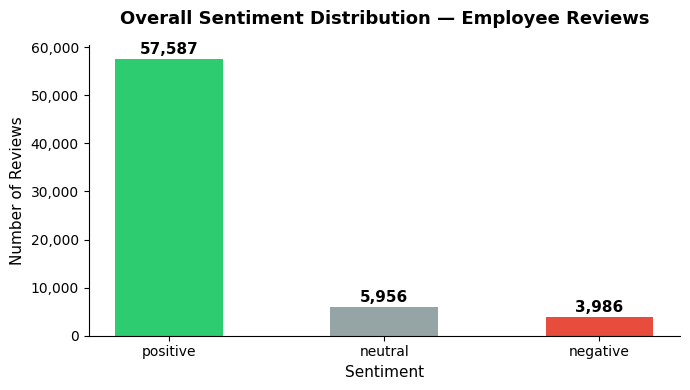

Saved: chart1_sentiment_distribution.png


In [25]:
fig, ax = plt.subplots(figsize=(7, 4))

sentiment_counts = df_clean['sentiment_label'].value_counts()
colors = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
bar_colors = [colors[s] for s in sentiment_counts.index]

bars = ax.bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, width=0.5)

for bar, val in zip(bars, sentiment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Overall Sentiment Distribution — Employee Reviews', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Sentiment', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_sentiment_distribution.png")

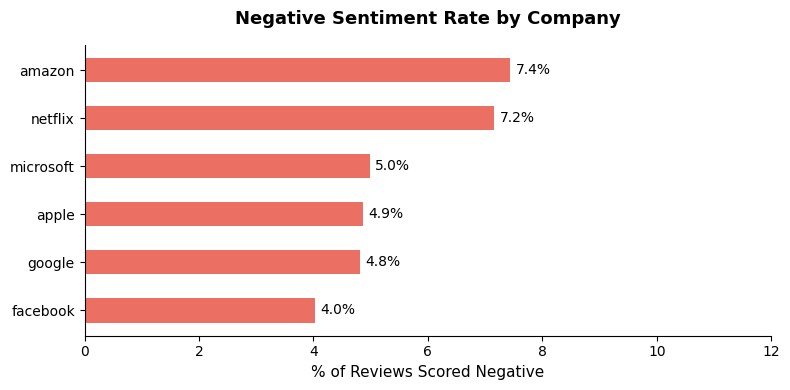

Saved: chart2_negative_by_company.png


In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

neg_by_company = df_clean[df_clean['sentiment_label'] == 'negative'] \
    .groupby('company').size() / df_clean.groupby('company').size() * 100
neg_by_company = neg_by_company.sort_values(ascending=True)

bars = ax.barh(neg_by_company.index, neg_by_company.values, color='#e74c3c', alpha=0.8, height=0.5)

for bar, val in zip(bars, neg_by_company.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_title('Negative Sentiment Rate by Company', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('% of Reviews Scored Negative', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, 12)
plt.tight_layout()
plt.savefig('chart2_negative_by_company.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart2_negative_by_company.png")

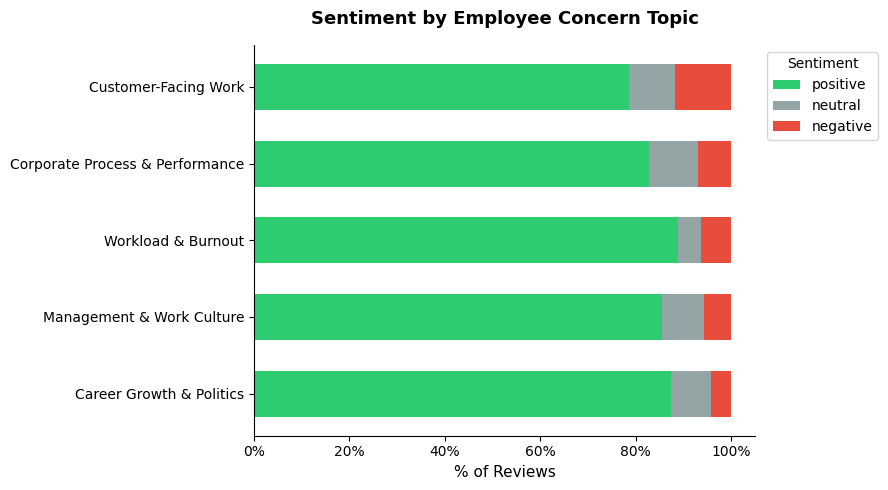

Saved: chart3_sentiment_by_topic.png


In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

topic_pct = pd.crosstab(
    df_clean['topic_name'],
    df_clean['sentiment_label'],
    normalize='index'
) * 100

topic_pct = topic_pct[['positive', 'neutral', 'negative']]
topic_pct = topic_pct.sort_values('negative', ascending=True)

topic_pct.plot(
    kind='barh',
    stacked=True,
    color=['#2ecc71', '#95a5a6', '#e74c3c'],
    ax=ax,
    width=0.6
)

ax.set_title('Sentiment by Employee Concern Topic', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('% of Reviews', fontsize=11)
ax.set_ylabel('')
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_sentiment_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart3_sentiment_by_topic.png")

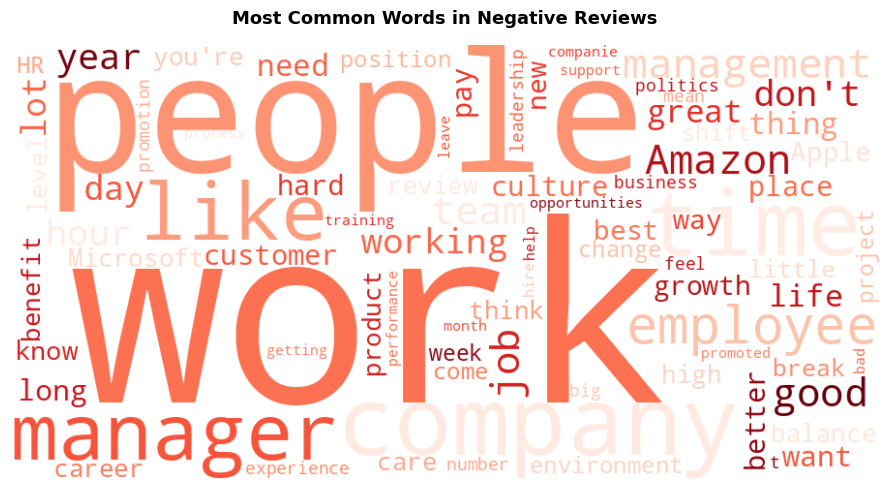

Saved: chart4_wordcloud_negative.png


In [28]:
negative_cons = df_clean[df_clean['sentiment_label'] == 'negative']['cons'].dropna()
negative_text = ' '.join(negative_cons.values)

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='white',
    colormap='Reds',
    max_words=80,
    stopwords=set(STOPWORDS),
    collocations=False
).generate(negative_text)

fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Words in Negative Reviews', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart4_wordcloud_negative.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart4_wordcloud_negative.png")

In [29]:
from google.colab import files
files.download('employee_reviews_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>